## MNIST Handwritten Digit Recognition

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.metrics import accuracy_score

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
(x_train, y_train),(x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_train[0].shape

(28, 28)

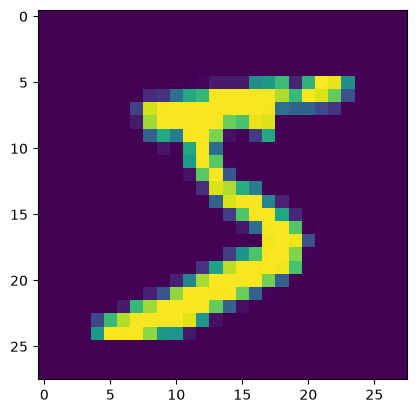

In [5]:
plt.imshow(x_train[0])
plt.show()

In [6]:
x_train = x_train/x_train.max()
x_test = x_test/x_test.max()

### ANN

In [7]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ flatten (Flatten)            │ (None, 784)           │            0 │
├──────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                │ (None, 128)           │      100,480 │
├──────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)              │ (None, 64)            │        8,256 │
├──────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)              │ (None, 10)            │          650 │
└──────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(metrics=['accuracy'], optimizer='Adam', loss='sparse_categorical_crossentropy')

In [10]:
history = model.fit(x_train, y_train, validation_split=0.2, verbose=2, batch_size=50, epochs=25)

Epoch 1/25
960/960 - 4s - 5ms/step - accuracy: 0.9165 - loss: 0.2927 - val_accuracy: 0.9566 - val_loss: 0.1521
Epoch 2/25
960/960 - 3s - 3ms/step - accuracy: 0.9642 - loss: 0.1208 - val_accuracy: 0.9646 - val_loss: 0.1147
Epoch 3/25
960/960 - 3s - 3ms/step - accuracy: 0.9756 - loss: 0.0818 - val_accuracy: 0.9689 - val_loss: 0.1032
Epoch 4/25
960/960 - 3s - 3ms/step - accuracy: 0.9812 - loss: 0.0602 - val_accuracy: 0.9734 - val_loss: 0.0920
Epoch 5/25
960/960 - 3s - 3ms/step - accuracy: 0.9854 - loss: 0.0462 - val_accuracy: 0.9736 - val_loss: 0.0885
Epoch 6/25
960/960 - 3s - 3ms/step - accuracy: 0.9874 - loss: 0.0378 - val_accuracy: 0.9736 - val_loss: 0.0941
Epoch 7/25
960/960 - 5s - 5ms/step - accuracy: 0.9893 - loss: 0.0324 - val_accuracy: 0.9718 - val_loss: 0.1058
Epoch 8/25
960/960 - 3s - 3ms/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.9746 - val_loss: 0.0990
Epoch 9/25
960/960 - 3s - 3ms/step - accuracy: 0.9928 - loss: 0.0206 - val_accuracy: 0.9724 - val_loss: 0.1106
E

In [19]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step


In [20]:
y_pred = y_pred.argmax(axis=1)

In [21]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [22]:
accuracy_score(y_test, y_pred)

0.9761

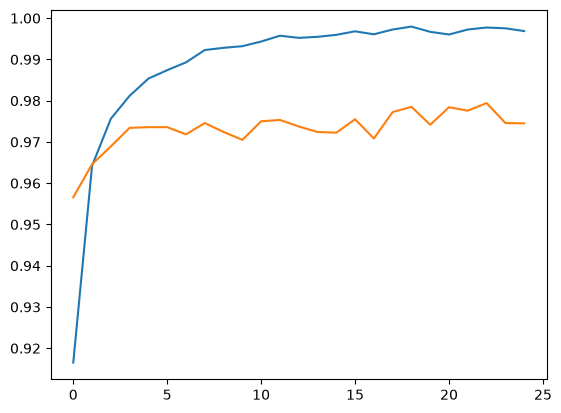

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.show()

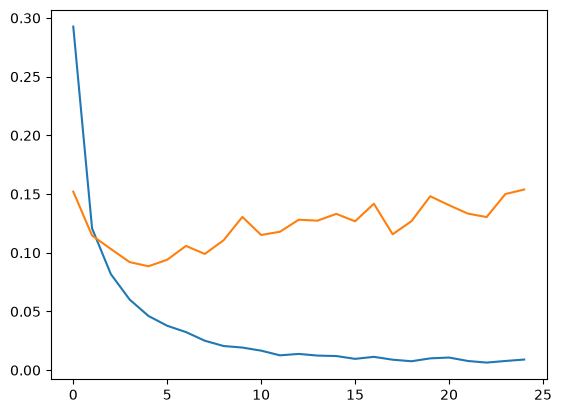

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()